In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('crop-yield.csv')
df.head()

,N,P,K,Soil_pH,Soil_Moisture,Soil_Type,Organic_Carbon,Temperature,Humidity,Rainfall,Sunlight_Hours,Wind_Speed,Region,Altitude,Season,Crop_Type,Irrigation_Type,Fertilizer_Used,Pesticide_Used,Crop_Yield_ton_per_hectare
0,132,62,22,6.35,59.78,Clay,0.43,22.97,53.89,1305.68,7.73,15.96,Central,36,Rabi,Maize,Canal,223.48,23.36,11.42
1,122,71,66,5.98,25.54,Sandy,0.65,17.00,76.90,1942.05,9.25,12.60,North,1561,Rabi,Potato,Canal,161.54,4.42,23.19
2,44,35,104,8.07,25.87,Sandy,0.79,25.52,44.78,2216.20,8.50,15.63,North,1870,Rabi,Rice,Rainfed,184.62,6.29,7.94
3,136,96,113,4.83,42.97,Silt,0.45,18.59,31.89,607.18,8.75,5.49,East,765,Kharif,Sugarcane,Rainfed,274.02,2.72,72.53
4,101,34,42,5.84,48.01,Silt,0.69,22.74,46.27,483.47,8.00,7.44,Central,1143,Zaid,Wheat,Rainfed,72.69,15.37,6.72


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   N                           10000 non-null  int64  
 1   P                           10000 non-null  int64  
 2   K                           10000 non-null  int64  
 3   Soil_pH                     10000 non-null  float64
 4   Soil_Moisture               10000 non-null  float64
 5   Soil_Type                   10000 non-null  object 
 6   Organic_Carbon              10000 non-null  float64
 7   Temperature                 10000 non-null  float64
 8   Humidity                    10000 non-null  float64
 9   Rainfall                    10000 non-null  float64
 10  Sunlight_Hours              10000 non-null  float64
 11  Wind_Speed                  10000 non-null  float64
 12  Region                      10000 non-null  object 
 13  Altitude                    1000

In [4]:
df.describe()

,N,P,K,Soil_pH,Soil_Moisture,Organic_Carbon,Temperature,Humidity,Rainfall,Sunlight_Hours,Wind_Speed,Altitude,Fertilizer_Used,Pesticide_Used,Crop_Yield_ton_per_hectare
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,104.983000,56.809600,85.008700,6.504306,40.083748,0.958356,25.097402,59.894209,1546.694887,7.507868,9.503192,1103.357200,205.986246,12.525571,22.342801
std,43.291654,24.522962,37.541443,0.978698,14.461944,0.375027,8.719031,17.402450,718.865960,2.006472,4.911870,636.513856,83.607922,7.215035,23.986065
min,30.000000,15.000000,20.000000,4.800000,15.000000,0.300000,10.000000,30.010000,300.700000,4.000000,1.000000,0.000000,60.000000,0.000000,1.760000
25%,68.000000,35.000000,52.000000,5.670000,27.630000,0.630000,17.590000,44.830000,925.767500,5.770000,5.230000,550.000000,133.337500,6.310000,8.280000
50%,105.000000,57.000000,85.000000,6.520000,40.000000,0.960000,24.970000,59.550000,1548.550000,7.530000,9.520000,1106.000000,205.820000,12.440000,10.270000
75%,142.000000,78.000000,118.000000,7.350000,52.762500,1.290000,32.830000,75.037500,2165.452500,9.220000,13.710000,1655.250000,278.090000,18.760000,24.750000
max,179.000000,99.000000,149.000000,8.200000,64.990000,1.600000,40.000000,89.990000,2799.260000,11.000000,18.000000,2199.000000,349.960000,25.000000,80.990000


In [5]:
df.isnull().sum()

N                             0
P                             0
K                             0
Soil_pH                       0
Soil_Moisture                 0
Soil_Type                     0
Organic_Carbon                0
Temperature                   0
Humidity                      0
Rainfall                      0
Sunlight_Hours                0
Wind_Speed                    0
Region                        0
Altitude                      0
Season                        0
Crop_Type                     0
Irrigation_Type               0
Fertilizer_Used               0
Pesticide_Used                0
Crop_Yield_ton_per_hectare    0
dtype: int64

Train Test Split

In [6]:
x=df.iloc[:,:-1]
y=df['Crop_Yield_ton_per_hectare']

In [7]:
#EDA processing

In [8]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
print(num_cols)

Index(['N', 'P', 'K', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon',
       'Temperature', 'Humidity', 'Rainfall', 'Sunlight_Hours', 'Wind_Speed',
       'Altitude', 'Fertilizer_Used', 'Pesticide_Used',
       'Crop_Yield_ton_per_hectare'],
      dtype='object')


In [9]:
outlier_count = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_count[col] = outliers.shape[0]

outlier_df = pd.DataFrame.from_dict(outlier_count, orient='index', columns=['Outlier_Count'])
print(outlier_df)

                            Outlier_Count
N                                       0
P                                       0
K                                       0
Soil_pH                                 0
Soil_Moisture                           0
Organic_Carbon                          0
Temperature                             0
Humidity                                0
Rainfall                                0
Sunlight_Hours                          0
Wind_Speed                              0
Altitude                                0
Fertilizer_Used                         0
Pesticide_Used                          0
Crop_Yield_ton_per_hectare           1633


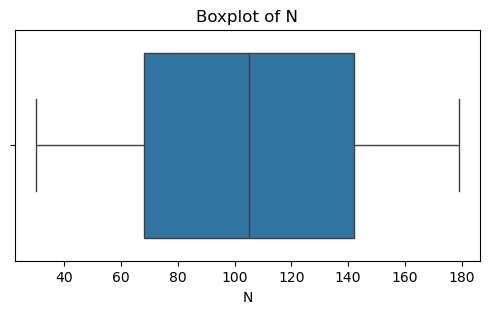

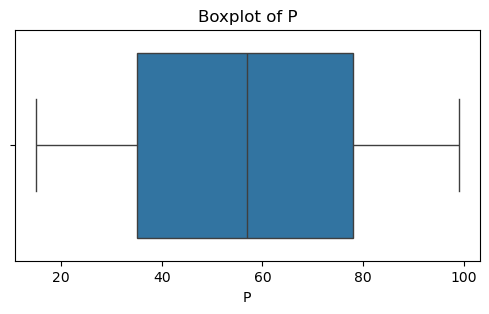

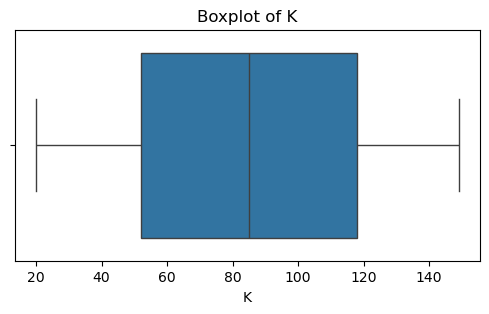

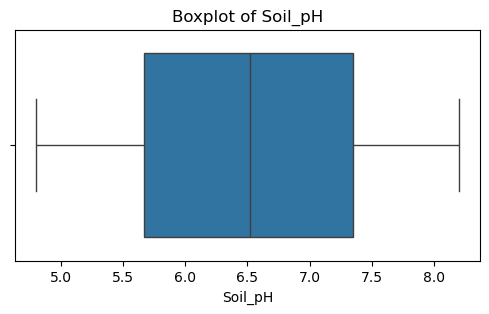

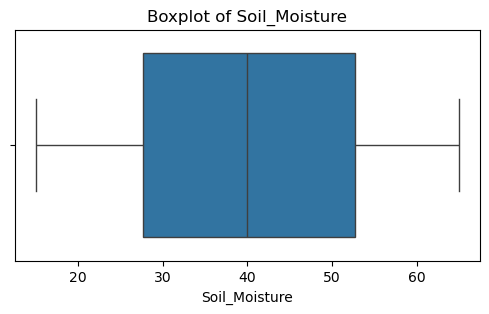

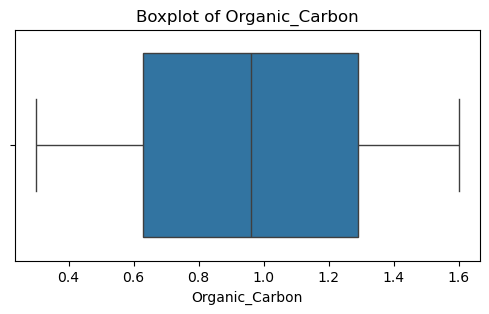

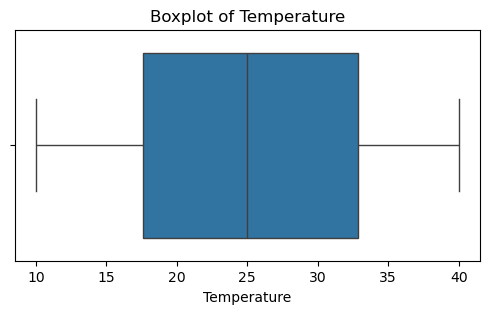

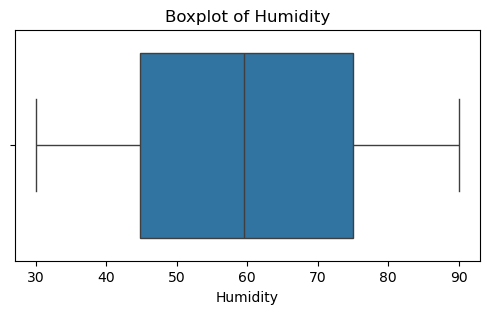

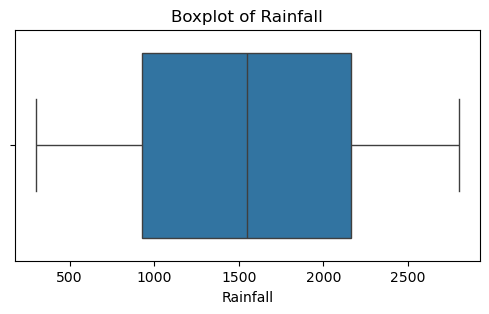

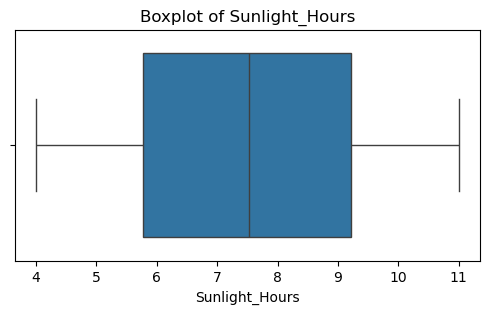

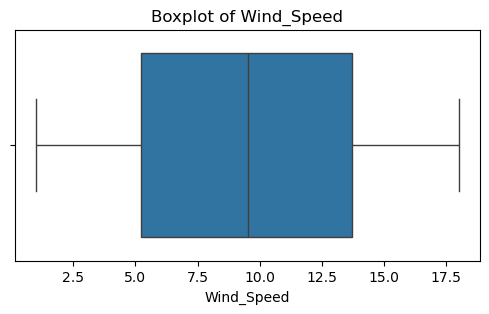

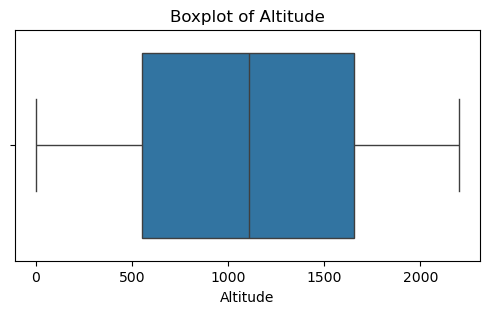

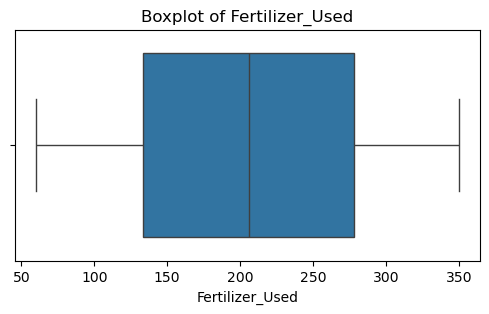

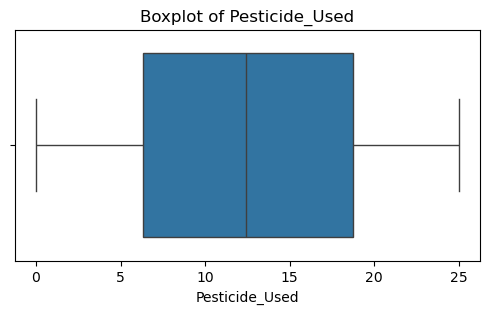

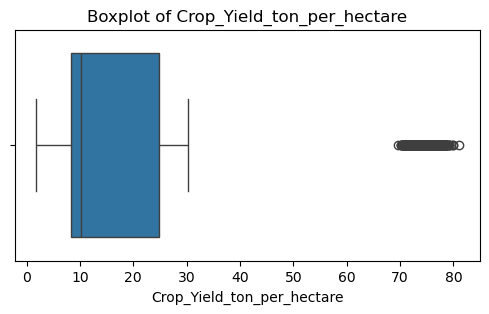

In [10]:
for col in num_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [11]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)


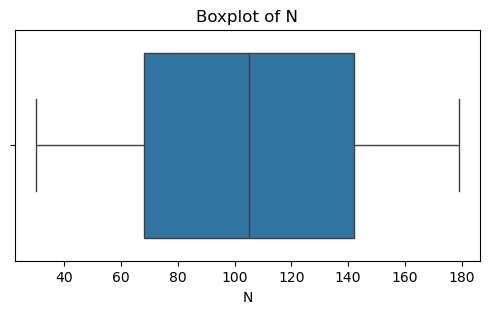

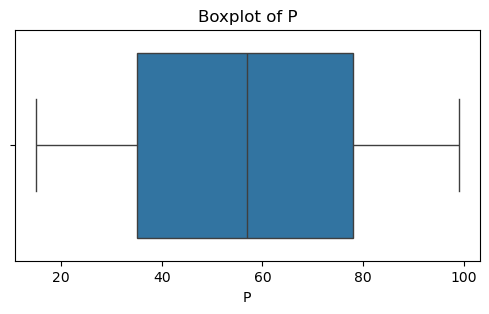

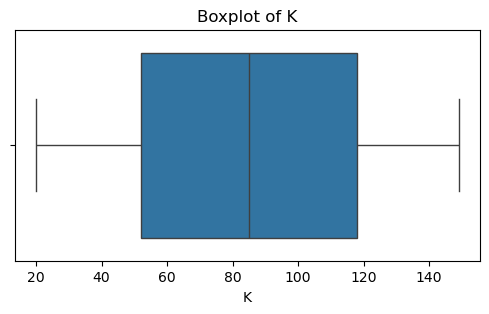

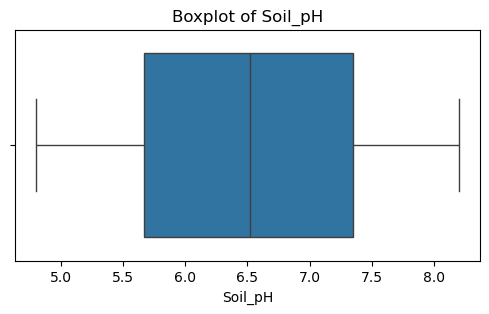

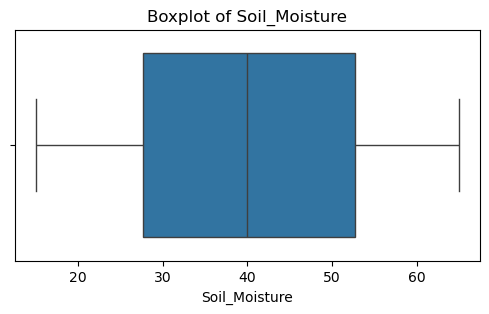

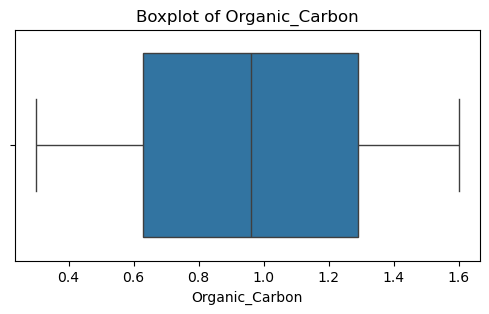

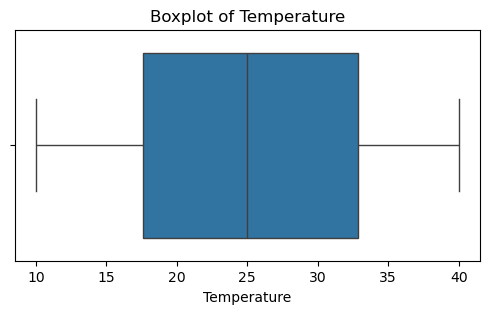

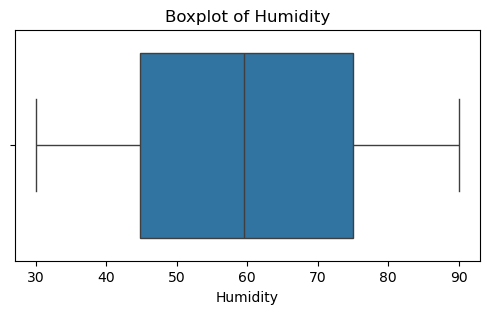

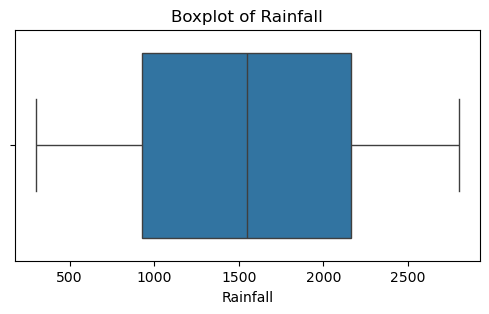

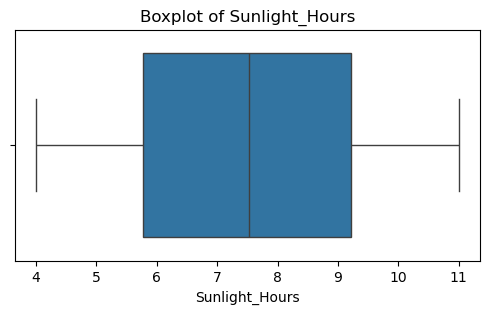

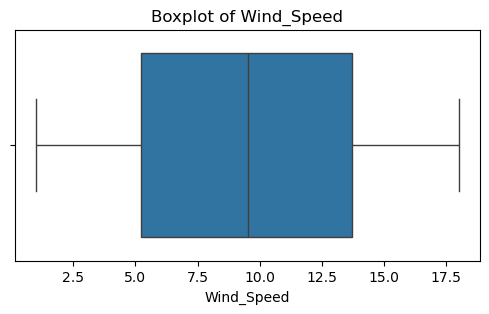

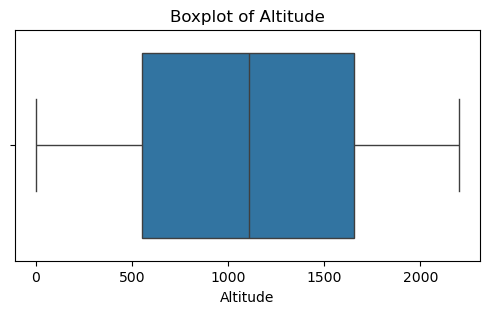

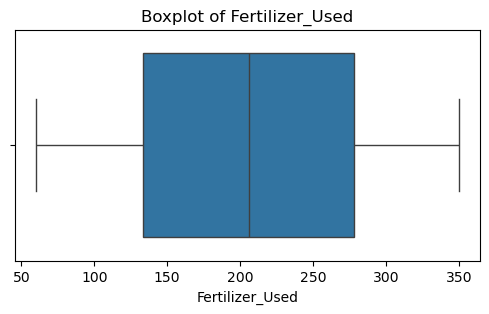

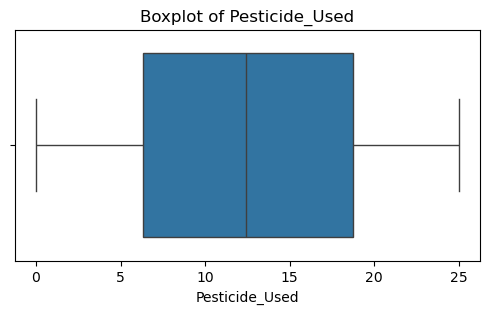

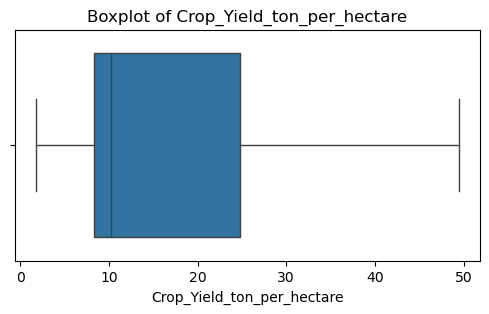

In [12]:
for col in num_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [13]:
df.head()

,N,P,K,Soil_pH,Soil_Moisture,Soil_Type,Organic_Carbon,Temperature,Humidity,Rainfall,Sunlight_Hours,Wind_Speed,Region,Altitude,Season,Crop_Type,Irrigation_Type,Fertilizer_Used,Pesticide_Used,Crop_Yield_ton_per_hectare
0,132,62,22,6.35,59.78,Clay,0.43,22.97,53.89,1305.68,7.73,15.96,Central,36,Rabi,Maize,Canal,223.48,23.36,11.420
1,122,71,66,5.98,25.54,Sandy,0.65,17.00,76.90,1942.05,9.25,12.60,North,1561,Rabi,Potato,Canal,161.54,4.42,23.190
2,44,35,104,8.07,25.87,Sandy,0.79,25.52,44.78,2216.20,8.50,15.63,North,1870,Rabi,Rice,Rainfed,184.62,6.29,7.940
3,136,96,113,4.83,42.97,Silt,0.45,18.59,31.89,607.18,8.75,5.49,East,765,Kharif,Sugarcane,Rainfed,274.02,2.72,49.455
4,101,34,42,5.84,48.01,Silt,0.69,22.74,46.27,483.47,8.00,7.44,Central,1143,Zaid,Wheat,Rainfed,72.69,15.37,6.720


In [14]:
#skewness removal
from scipy.stats import skew

N
-0.011351777224851525


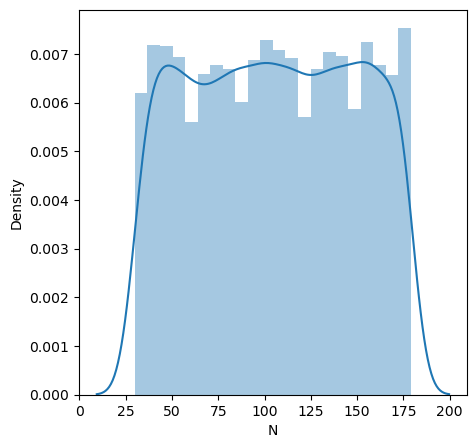

P
0.010378163231537566


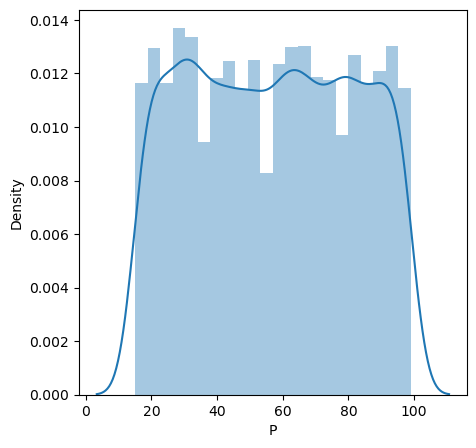

K
-0.014532248470137586


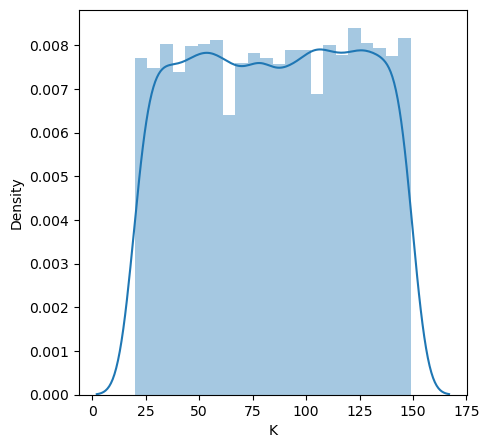

Altitude
-0.004547515667619595


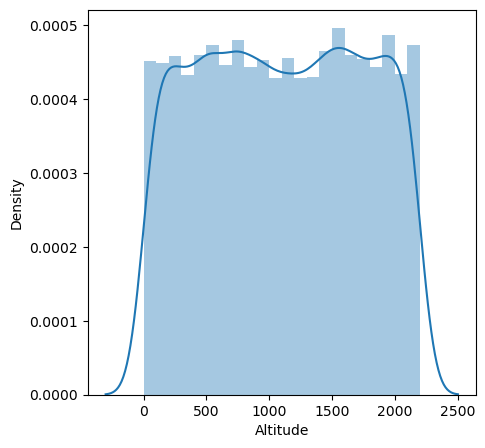

In [15]:

col=x.select_dtypes('int','float').columns
for i in x[col]:
    print(i)
    print(skew(x[i]))
    plt.figure(figsize=(5,5))
    sns.distplot(x[i])
    plt.show()

In [16]:
pd.concat([x,y],axis=1).corr(numeric_only=True).style.background_gradient()

,N,P,K,Soil_pH,Soil_Moisture,Organic_Carbon,Temperature,Humidity,Rainfall,Sunlight_Hours,Wind_Speed,Altitude,Fertilizer_Used,Pesticide_Used,Crop_Yield_ton_per_hectare
N,1.000000,0.005533,-0.006166,0.007986,0.011550,0.010804,0.002322,0.007482,0.007888,-0.007339,0.004930,0.003880,0.010153,-0.000861,0.002334
P,0.005533,1.000000,-0.004304,-0.004621,-0.015392,0.010566,-0.001248,0.005704,-0.000457,0.026856,0.008617,0.009788,0.004610,-0.008628,-0.002483
K,-0.006166,-0.004304,1.000000,-0.001930,0.009864,-0.008846,0.011868,0.010564,-0.005509,-0.000492,0.003925,-0.003673,0.008445,-0.003456,0.009897
Soil_pH,0.007986,-0.004621,-0.001930,1.000000,-0.005134,0.005676,-0.000429,0.000018,0.001366,-0.001607,-0.000314,-0.001439,0.000290,0.011209,-0.010509
Soil_Moisture,0.011550,-0.015392,0.009864,-0.005134,1.000000,0.000630,-0.006193,-0.012790,-0.006895,-0.007630,0.000661,0.008936,-0.008293,0.008485,0.000152
Organic_Carbon,0.010804,0.010566,-0.008846,0.005676,0.000630,1.000000,-0.022291,0.000826,-0.009739,-0.003171,0.013330,0.022276,-0.001069,-0.001418,-0.000781
Temperature,0.002322,-0.001248,0.011868,-0.000429,-0.006193,-0.022291,1.000000,-0.008862,-0.005747,0.000798,-0.010281,0.003325,-0.012319,0.009531,-0.006589
Humidity,0.007482,0.005704,0.010564,0.000018,-0.012790,0.000826,-0.008862,1.000000,0.012658,0.021042,-0.002977,-0.002748,-0.009715,-0.001629,0.006916
Rainfall,0.007888,-0.000457,-0.005509,0.001366,-0.006895,-0.009739,-0.005747,0.012658,1.000000,-0.001289,-0.014392,-0.000546,0.018513,-0.007375,0.031213
Sunlight_Hours,-0.007339,0.026856,-0.000492,-0.001607,-0.007630,-0.003171,0.000798,0.021042,-0.001289,1.000000,-0.003318,0.016818,-0.008959,-0.002348,-0.001162


In [17]:
x.head()

,N,P,K,Soil_pH,Soil_Moisture,Soil_Type,Organic_Carbon,Temperature,Humidity,Rainfall,Sunlight_Hours,Wind_Speed,Region,Altitude,Season,Crop_Type,Irrigation_Type,Fertilizer_Used,Pesticide_Used
0,132,62,22,6.35,59.78,Clay,0.43,22.97,53.89,1305.68,7.73,15.96,Central,36,Rabi,Maize,Canal,223.48,23.36
1,122,71,66,5.98,25.54,Sandy,0.65,17.00,76.90,1942.05,9.25,12.60,North,1561,Rabi,Potato,Canal,161.54,4.42
2,44,35,104,8.07,25.87,Sandy,0.79,25.52,44.78,2216.20,8.50,15.63,North,1870,Rabi,Rice,Rainfed,184.62,6.29
3,136,96,113,4.83,42.97,Silt,0.45,18.59,31.89,607.18,8.75,5.49,East,765,Kharif,Sugarcane,Rainfed,274.02,2.72
4,101,34,42,5.84,48.01,Silt,0.69,22.74,46.27,483.47,8.00,7.44,Central,1143,Zaid,Wheat,Rainfed,72.69,15.37


Encoding

In [18]:
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder

In [19]:
cat_col=x.select_dtypes('object').columns
cat_col

Index(['Soil_Type', 'Region', 'Season', 'Crop_Type', 'Irrigation_Type'], dtype='object')

In [20]:
ohe = OneHotEncoder(sparse_output=False)

encoded = ohe.fit_transform(df[cat_col])

encoded_df = pd.DataFrame(
    encoded,
    columns=ohe.get_feature_names_out(cat_col),
    index=df.index
)

# Drop old categorical columns
df = df.drop(columns=cat_col)

# Concatenate encoded columns
df = pd.concat([encoded_df,df], axis=1)
df.head()

,Soil_Type_Clay,Soil_Type_Loamy,Soil_Type_Sandy,Soil_Type_Silt,Region_Central,Region_East,Region_North,Region_South,Region_West,Season_Kharif,...,Organic_Carbon,Temperature,Humidity,Rainfall,Sunlight_Hours,Wind_Speed,Altitude,Fertilizer_Used,Pesticide_Used,Crop_Yield_ton_per_hectare
0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.43,22.97,53.89,1305.68,7.73,15.96,36,223.48,23.36,11.420
1,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.65,17.00,76.90,1942.05,9.25,12.60,1561,161.54,4.42,23.190
2,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.79,25.52,44.78,2216.20,8.50,15.63,1870,184.62,6.29,7.940
3,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.45,18.59,31.89,607.18,8.75,5.49,765,274.02,2.72,49.455
4,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.69,22.74,46.27,483.47,8.00,7.44,1143,72.69,15.37,6.720


In [21]:
x=df.iloc[:,:-1]
y=df['Crop_Yield_ton_per_hectare']

In [22]:
#Scaling
from sklearn.preprocessing import StandardScaler
mn=StandardScaler()
x.iloc[:,:]=mn.fit_transform(x.iloc[:,:])
x.head()

,Soil_Type_Clay,Soil_Type_Loamy,Soil_Type_Sandy,Soil_Type_Silt,Region_Central,Region_East,Region_North,Region_South,Region_West,Season_Kharif,...,Soil_Moisture,Organic_Carbon,Temperature,Humidity,Rainfall,Sunlight_Hours,Wind_Speed,Altitude,Fertilizer_Used,Pesticide_Used
0,1.747428,-0.583971,-0.576734,-0.576427,2.011320,-0.500937,-0.500469,-0.50203,-0.499375,-0.709760,...,1.362005,-1.408919,-0.244007,-0.345038,-0.335288,0.110713,1.314597,-1.676964,0.209246,1.501721
1,-0.572269,-0.583971,1.733900,-0.576427,-0.497186,-0.500937,1.998127,-0.50203,-0.499375,-0.709760,...,-1.005707,-0.822265,-0.928751,0.977256,0.549998,0.868300,0.630506,0.719019,-0.531630,-1.123484
2,-0.572269,-0.583971,1.733900,-0.576427,-0.497186,-0.500937,1.998127,-0.50203,-0.499375,-0.709760,...,-0.982887,-0.448940,0.048471,-0.868554,0.931382,0.494491,1.247410,1.204500,-0.255566,-0.864290
3,-0.572269,-0.583971,-0.576734,1.734827,-0.497186,1.996258,-0.500469,-0.50203,-0.499375,1.408927,...,0.199586,-1.355587,-0.746382,-1.609291,-1.307006,0.619094,-0.817080,-0.531605,0.813764,-1.359115
4,-0.572269,-0.583971,-0.576734,1.734827,2.011320,-0.500937,-0.500469,-0.50203,-0.499375,-0.709760,...,0.548104,-0.715601,-0.270388,-0.782929,-1.479105,0.245285,-0.420063,0.062284,-1.594381,0.394256


Split data

In [23]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.20,random_state=1)


In [24]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()

#train the model
lr.fit(xtrain,ytrain)

#predict the obs
ypred=lr.predict(xtest)

In [25]:
lr.coef_

array([-1.80429218e-02,  7.98606594e-03,  1.09870069e-02, -1.05048211e-03,
       -7.06066231e-04,  5.06532945e-03,  1.16994840e-02, -1.02305283e-03,
       -1.50591749e-02,  5.51787145e-03, -3.35917619e-03, -2.16644438e-03,
       -4.02324312e+00, -3.02877259e+00,  2.50620959e+00, -3.33027102e+00,
        1.15374590e+01, -3.54461084e+00, -9.84953951e-03,  1.24477554e-02,
       -1.69498834e-03, -9.25056830e-04,  1.90463800e-01,  1.12911829e-01,
        1.54844545e-01, -3.67846059e-03,  3.68495453e-01,  1.05569689e-03,
       -7.97323804e-03,  8.24628296e-03,  6.09001790e-01,  2.78030204e-02,
       -2.19625393e-01,  2.67014679e-02,  7.28250459e-01,  8.64573836e-05])

In [26]:
lr.intercept_

np.float64(18.202477207941165)

Evaluation Metrics

Accuracy

In [27]:
from sklearn.metrics import r2_score
r2_score(ytest,ypred)

0.9948983220079698

In [28]:
from sklearn.metrics import mean_absolute_error,mean_squared_error
print(mean_absolute_error(ytest,ypred))
print(mean_squared_error(ytest,ypred))
print(np.sqrt(mean_squared_error(ytest,ypred)))

0.8803953989663391
1.1834207864238082
1.0878514542086195


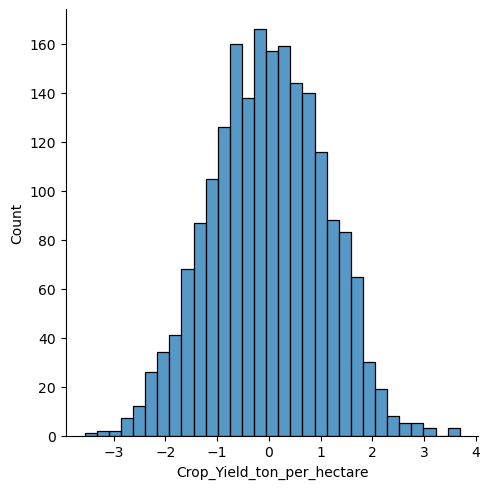

In [29]:
sns.displot(ytest-ypred)

KNN

In [30]:
from sklearn.neighbors import KNeighborsRegressor
knn=KNeighborsRegressor(n_neighbors=6)
knn.fit(xtrain,ytrain)
ypred=knn.predict(xtest)

In [31]:
from sklearn.metrics import r2_score,accuracy_score


In [32]:
r2_score(ytest,ypred)

0.9598889642321407

HPT

In [33]:
ac_list=[]
for i in range(1,100):
    knn=KNeighborsRegressor(n_neighbors=i)
    knn.fit(xtrain,ytrain)
    ypred=knn.predict(xtest)
    ac=r2_score(ytest,ypred)
    ac_list.append(ac)

In [34]:
ac_list


[0.9602047996550372,
 0.9533842060040605,
 0.9518669178940887,
 0.9566968123083276,
 0.9580102865969918,
 0.9598889642321407,
 0.9592576327046102,
 0.9594138231276136,
 0.9598908711121537,
 0.9592018352114874,
 0.9599373295683119,
 0.9594777698198257,
 0.9593967430732235,
 0.9591400567090582,
 0.9588745154024202,
 0.9583569077625197,
 0.9582929445527236,
 0.9575581926593092,
 0.9572094225252974,
 0.9565767254655927,
 0.9562980927965524,
 0.9556454803812964,
 0.9549642675374053,
 0.9539521005120739,
 0.9535770970759387,
 0.952828060302446,
 0.9520530116553757,
 0.9511832947238695,
 0.9504502268284841,
 0.9493687009642513,
 0.9488908290628426,
 0.948372369795294,
 0.9474281432619487,
 0.947017483716942,
 0.9461814457631292,
 0.9459543522064184,
 0.9456737099045708,
 0.9446357060784532,
 0.9439463437819203,
 0.9430915180474035,
 0.942334357656049,
 0.9413726284345932,
 0.9405665657808868,
 0.9397026634864514,
 0.9388684628502798,
 0.937885662162013,
 0.9371495499105941,
 0.936057002728488

In [35]:
knn=KNeighborsRegressor(n_neighbors=76)
knn.fit(xtrain,ytrain)
ypred=knn.predict(xtest)

In [36]:
print(r2_score(ytest,ypred))

0.9179089902350096


SVM

In [37]:
from sklearn.svm import SVR


In [38]:
svm=SVR()

In [39]:
def mymodel(model):
    model.fit(xtrain,ytrain)
    ypred=model.predict(xtest)
    print(r2_score(ytest,ypred))
    return model

In [40]:
mymodel(knn)

0.9179089902350096


,n_neighbors,76
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [41]:
mymodel(svm)

0.9870201182571006


,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [42]:
svm=SVR(kernel='linear')
mymodel(svm)

0.9948955766960326


,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [43]:
svm=SVR(kernel='poly')
mymodel(svm)

0.9709814778766053


,kernel,'poly'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [44]:
svm=SVR(kernel='sigmoid')
mymodel(svm)

0.9870080497155526


,kernel,'sigmoid'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


Hypertunning

In [45]:
from sklearn.model_selection import GridSearchCV

In [46]:
param_grid={'C':[10,20],'gamma':[10,20],'kernel':['linear']}

In [47]:
gs=GridSearchCV(svm,param_grid,verbose=3)
gs.fit(xtrain,ytrain)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
[CV 1/5] END .....C=10, gamma=10, kernel=linear;, score=0.994 total time=  59.6s
[CV 2/5] END .....C=10, gamma=10, kernel=linear;, score=0.994 total time=  57.1s
[CV 3/5] END .....C=10, gamma=10, kernel=linear;, score=0.994 total time=  57.5s
[CV 4/5] END .....C=10, gamma=10, kernel=linear;, score=0.995 total time=  59.3s
[CV 5/5] END .....C=10, gamma=10, kernel=linear;, score=0.995 total time= 1.6min
[CV 1/5] END .....C=10, gamma=20, kernel=linear;, score=0.994 total time=  58.8s
[CV 2/5] END .....C=10, gamma=20, kernel=linear;, score=0.994 total time=  58.0s
[CV 3/5] END .....C=10, gamma=20, kernel=linear;, score=0.994 total time=  59.1s
[CV 4/5] END .....C=10, gamma=20, kernel=linear;, score=0.995 total time=  57.6s
[CV 5/5] END .....C=10, gamma=20, kernel=linear;, score=0.995 total time= 1.0min
[CV 1/5] END .....C=20, gamma=10, kernel=linear;, score=0.994 total time= 1.8min
[CV 2/5] END .....C=20, gamma=10, kernel=linear;,

,estimator,SVR(kernel='sigmoid')
,param_grid,"{'C': [10, 20], 'gamma': [10, 20], 'kernel': ['linear']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,kernel,'linear'


In [48]:
gs.best_params_

{'C': 20, 'gamma': 10, 'kernel': 'linear'}

In [49]:
gs.best_estimator_

,kernel,'linear'
,degree,3
,gamma,10
,coef0,0.0
,tol,0.001
,C,20
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [50]:
svm=gs.best_estimator_
svm.fit(xtrain,ytrain)
ypred=svm.predict(xtest)

In [51]:
r2_score(ytest,ypred)

0.994896479458339

DecisionTree

In [52]:
from sklearn.tree import DecisionTreeRegressor
from sklearn import tree

In [53]:
dt=DecisionTreeRegressor()

In [54]:
mymodel(dt)

0.9900595908174248


,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


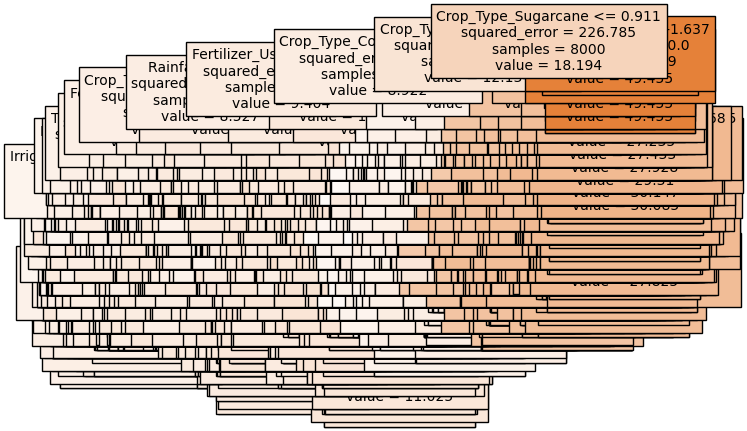

In [55]:
tree.plot_tree(dt,feature_names=x.columns,filled=True,fontsize=10)
plt.savefig('crop.jpg')

In [56]:
print(dt.score(xtrain,ytrain))
print(dt.score(xtest,ytest))

1.0
0.9900595908174248


Pruning techniques 1.max depth 2.min

In [57]:
for i in range(1,30):
    dt1=DecisionTreeRegressor(max_depth=i)
    dt1.fit(xtrain,ytrain)
    ypred=dt1.predict(xtest)

    ac=r2_score(ytest,ypred)
    print(f"Max_depth{i} accuracy{ac}")

Max_depth1 accuracy0.8431482648121646
Max_depth2 accuracy0.9872428282156569
Max_depth3 accuracy0.9898419336058198
Max_depth4 accuracy0.9915688905302509
Max_depth5 accuracy0.9926954380313353
Max_depth6 accuracy0.9933659406360923
Max_depth7 accuracy0.9936175897398478
Max_depth8 accuracy0.9937595987032535
Max_depth9 accuracy0.993367278027713
Max_depth10 accuracy0.9929581020336857
Max_depth11 accuracy0.9925147610506639
Max_depth12 accuracy0.9916732677601595
Max_depth13 accuracy0.991221354689364
Max_depth14 accuracy0.9907646050370431
Max_depth15 accuracy0.9904731017667193
Max_depth16 accuracy0.9902466771551253
Max_depth17 accuracy0.9902276182335602
Max_depth18 accuracy0.9903419432723467
Max_depth19 accuracy0.9899654912843657
Max_depth20 accuracy0.9899846063556277
Max_depth21 accuracy0.99010914332377
Max_depth22 accuracy0.9900119418979274
Max_depth23 accuracy0.9900418966735473
Max_depth24 accuracy0.9900706196871751
Max_depth25 accuracy0.9902165452751157
Max_depth26 accuracy0.9900462132663098

In [78]:
dt2=DecisionTreeRegressor(max_depth=3)
mymodel(dt2)

0.9898419336058198


,criterion,'squared_error'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [79]:
#check overfitting
print(dt2.score(xtrain,ytrain))
print(dt2.score(xtest,ytest))

0.989153617606629
0.9898419336058198


In [80]:
#min_samples_leaf
for i in range(1,30):
    dt3=DecisionTreeRegressor(min_samples_leaf=i)
    dt3.fit(xtrain,ytrain)
    ypred=dt3.predict(xtest)

    ac=r2_score(ytest,ypred)
    print(f"Min_samples_leaf{i} accuracy{ac}")

Min_samples_leaf1 accuracy0.9898444147086426
Min_samples_leaf2 accuracy0.9905861878436942
Min_samples_leaf3 accuracy0.991275973763444
Min_samples_leaf4 accuracy0.9915735274967811
Min_samples_leaf5 accuracy0.9919900969983315
Min_samples_leaf6 accuracy0.9923073304497698
Min_samples_leaf7 accuracy0.9924887147743141
Min_samples_leaf8 accuracy0.9928166774289635
Min_samples_leaf9 accuracy0.9929913424816972
Min_samples_leaf10 accuracy0.992962489722693
Min_samples_leaf11 accuracy0.9930784347585617
Min_samples_leaf12 accuracy0.9932415795786821
Min_samples_leaf13 accuracy0.9933523801250358
Min_samples_leaf14 accuracy0.9934369943255694
Min_samples_leaf15 accuracy0.9935334358317245
Min_samples_leaf16 accuracy0.9936477504982854
Min_samples_leaf17 accuracy0.9937580064098865
Min_samples_leaf18 accuracy0.9937796932771017
Min_samples_leaf19 accuracy0.9938174427053887
Min_samples_leaf20 accuracy0.9938070869040632
Min_samples_leaf21 accuracy0.993845832086775
Min_samples_leaf22 accuracy0.9938585845560036


In [82]:
dt4=DecisionTreeRegressor(min_samples_leaf=28)
mymodel(dt4)

0.9940003183459646


,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,28
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [83]:
print(dt4.score(xtrain,ytrain))
print(dt4.score(xtest,ytest))

0.9956011058844559
0.9940003183459646


In [84]:

#min_samples_split
for i in range(2,30):
    dt5=DecisionTreeRegressor(min_samples_split=i)
    dt5.fit(xtrain,ytrain)
    ypred=dt5.predict(xtest)

    ac=r2_score(ytest,ypred)
    print(f"Min_samples_split{i} accuracy{ac}")

Min_samples_split2 accuracy0.9899560002071502
Min_samples_split3 accuracy0.9901066947757753
Min_samples_split4 accuracy0.990334995855412
Min_samples_split5 accuracy0.9903285575645102
Min_samples_split6 accuracy0.9904884182804338
Min_samples_split7 accuracy0.9905943491319946
Min_samples_split8 accuracy0.990803880268298
Min_samples_split9 accuracy0.9908860975213222
Min_samples_split10 accuracy0.9911008230826092
Min_samples_split11 accuracy0.9911464684223771
Min_samples_split12 accuracy0.9913120511755448
Min_samples_split13 accuracy0.991277744852146
Min_samples_split14 accuracy0.9914828320151676
Min_samples_split15 accuracy0.9916257110754803
Min_samples_split16 accuracy0.9917208957143642
Min_samples_split17 accuracy0.9918039814311159
Min_samples_split18 accuracy0.9918465353473405
Min_samples_split19 accuracy0.9920692336953378
Min_samples_split20 accuracy0.9921552074204467
Min_samples_split21 accuracy0.992196432490631
Min_samples_split22 accuracy0.9922422948135337
Min_samples_split23 accur

In [85]:
dt6=DecisionTreeRegressor(min_samples_split=100)
mymodel(dt6)

0.9940053335767768


,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,100
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [86]:
print(dt6.score(xtrain,ytrain))
print(dt6.score(xtest,ytest))

0.9951926988993951
0.9940053335767768


Ensemble Learning-->bagging and boosting

In [87]:
from sklearn.ensemble import BaggingRegressor,RandomForestRegressor

bagging

In [88]:
bg=BaggingRegressor(LinearRegression())

In [89]:
mymodel(bg)

0.9948975424027932


,estimator,LinearRegression()
,n_estimators,10
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,None
,random_state,None
,verbose,0


In [90]:
rf=RandomForestRegressor()
mymodel(rf)

0.9954176615194006


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [91]:
from sklearn.ensemble import VotingRegressor

In [92]:
model=[]
model.append(('LR',LinearRegression()))
model.append(('DT',DecisionTreeRegressor()))

In [93]:
vr=VotingRegressor(estimators=model)
mymodel(vr)

0.9940886911161124


,estimators,"[('LR', ...), ('DT', ...)]"
,weights,None
,n_jobs,None
,verbose,False
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False
,criterion,'squared_error'
,splitter,'best'


Boosting

In [94]:
from sklearn.ensemble import AdaBoostRegressor,GradientBoostingRegressor

In [95]:
ada=AdaBoostRegressor()
mymodel(ada)

0.9929802920822439


,estimator,None
,n_estimators,50
,learning_rate,1.0
,loss,'linear'
,random_state,None


In [96]:
gb=GradientBoostingRegressor()
mymodel(gb)

0.9959202035772909


,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [97]:
from xgboost import XGBRegressor

In [98]:
xgb=XGBRegressor()
mymodel(xgb)

0.9954166641947857


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None
